In [1]:
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft
from IPython.display import Latex

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output',
#                    305, basename='snapshot')
# center = snap.Cat.Group['GroupPos'][0]
# widths = np.array([1e3, 1e3, 1e3], dtype=float)

# m_filter = 1000*snap.mass
# filter_length = (np.cbrt(3*m_filter/(4*np.pi*snap['0_Density']))).arepo
# filter_length = 2.0*snap['0_Diameters']
# weight='0_Volume'
# filter_type = 'gaussian'



In [2]:
import cmasher as cmr
get_ipython().run_line_magic('matplotlib', 'widget')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

grays = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))
blues = plt.cm.Blues_r(np.linspace(0,1,10))
greens = plt.cm.Greens_r(np.linspace(0,1,10))
oranges = plt.cm.Oranges_r(np.linspace(0,1,10))

# plt.rc('font', family='serif')
# plt.rcParams['font.serif'] = 'ITC Bookman'
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 1.7
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.labelsize']= 16
plt.rcParams['ytick.labelsize']= 16
plt.rcParams['xtick.minor.size']= 4.0
plt.rcParams['ytick.minor.size']= 4.0
plt.rcParams['xtick.major.size']= 5.0
plt.rcParams['ytick.major.size']= 5.0
plt.rcParams['xtick.minor.width']= 0.7
plt.rcParams['ytick.minor.width']= 0.7
plt.rcParams['xtick.major.width']= 1.
plt.rcParams['ytick.major.width']= 1.

plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'


In [3]:
@cuda.jit(lineinfo=True)
def _gpu_power_spectrum1d(vhat, wavenum, Ngrid, powerspectr, type):
    # vhat has shape: 
    # (Nx,Ny,Nz) if complex transform, or
    # (Nx,Ny,Nz//2+1) if real transform
    # Ngrid is a tuple with the dimension
    # of the real grid (Nx, Ny, Nz)
    # Ncomplex is a tuple with the dimension
    # of the complex grid:
    # (Nx, Ny, Nz) if C2C
    # (Nx, Ny, Nz//2+1) if R2C
    # type = 0 for real fft
    # type = 1 for complex fft
    
    Nx, Ny, Nz = Ngrid
    ntotal = Nx*Ny*Nz
    ncomplex_kx, ncomplex_ky, ncomplex_kz = vhat.shape
    ntotal_complex = ncomplex_kx * ncomplex_ky * ncomplex_kz
    
    ip = cuda.grid(1)

    if (ip < ntotal_complex):
        k = ip % ncomplex_kz
        ip_tmp = int((ip - k)/ncomplex_kz)
        j = ip_tmp % ncomplex_ky
        i = ip_tmp // ncomplex_ky

        power_at_freq = (vhat[i,j,k] * vhat[i,j,k].conjugate() ).real

        # this is more properly the *wavenumber*
        # (not wavevector), i.e. it says which frequency
        # bin it belongs to
        freq = int(wavenum[i,j,k] + 0.5)
        # # if we are doing a real fft
        # # we need to double to take into account
        # # energy contained in the negative KZ midplane
        # if (k > 0 and (ncomplex_kz - 1) % (Nz//2) == 0): 
        # if (k > 0 and not ncomplex_kz == Nz): 
        if (k > 0 and not type == 1): 
        # if (k > 0):
            power_at_freq *= 2.0

        # for spectral energy density
        cuda.atomic.add(powerspectr, (freq), 
                        power_at_freq / (ntotal**2))
        # cuda.atomic.add(powerspectr, (freq), 
        #                 power_at_freq )

@cuda.jit(lineinfo=True)
def _gpu_power_spectrum1d_finufft(vhat, wavenum, Ngrid, Ncomplex, powerspectr, M):
    # vhat has shape: 
    # (Nx,Ny,Nz) if complex transform, or
    # (Nx,Ny,Nz//2+1) if real transform
    # Ngrid is a tuple with the dimension
    # of the real grid (Nx, Ny, Nz)
    # Ncomplex is a tuple with the dimension
    # of the complex grid:
    # (Nx, Ny, Nz) if C2C
    # (Nx, Ny, Nz//2+1) if R2C
    # M is the original length of the sampling points in finufft
    
    Nx, Ny, Nz = Ngrid
    ntotal = Nx*Ny*Nz
    ncomplex_kx, ncomplex_ky, ncomplex_kz = Ncomplex
    ntotal_complex = ncomplex_kx * ncomplex_ky * ncomplex_kz
    
    ip = cuda.grid(1)

    if (ip < ntotal_complex):
        k = ip % ncomplex_kz
        ip_tmp = int((ip - k)/ncomplex_kz)
        j = ip_tmp % ncomplex_ky
        i = ip_tmp // ncomplex_ky
    
        # kx =  ( i +  float(Nx) / 2.0) %  Nx  - Nx / 2 
        # ky =  ( j +  float(Ny) / 2.0) %  Ny  - Ny / 2 
        # if (ncomplex_kz == Nz//2 + 1):
        #     kz = k
        # else:
        #     kz =  ( k +  float(Nz) / 2.0) %  Nz  - Nz / 2 

        # # this is to take into account that 
        # # the widths of the region can be different
        # # but the Ny,Nz are chosen such that
        # # the spacing is uniform in all 3 directions
        # ky *= Nx / Ny
        # kz *= Nx / Nz

        power_at_freq = (vhat[i,j,k] * vhat[i,j,k].conjugate() ).real
        
        freq = int(wavenum[i,j,k] + 0.5)
        # # if we are doing a real fft
        # # we need to double to take into account
        # # energy contained in the negative KZ midplane
        if (k > 0 and (ncomplex_kz - 1) % (Nz//2) == 0): 
        # if (k > 0):
            power_at_freq *= 2.0
    
        # powerspectr[0,0,0] = i
        # cuda.atomic.add(powerspectr, (freq), 
        #                 power_at_freq / ((Nx*Ny*Nz)**2))
        cuda.atomic.add(powerspectr, (freq), 
                        power_at_freq / (M**2))
        
def power_spectrum1d_gpu(vhat, Ngrid, widths, finufft=False, FFTtype="real", M=-1, **kwargs):
    # vhat has shape: 
    # (Nx,Ny,Nz) if complex transform, or
    # (Nx,Ny,Nz//2+1) if real transform
    # Ngrid is a tuple with the dimension
    # of the real grid (Nx, Ny, Nz)
    # widths is a tuple with the physical
    # size of the grid (Lx, Ly, Lz)
        
    Nx, Ny, Nz = Ngrid
    Ntotalcomplex = vhat.shape[0]*vhat.shape[1]*vhat.shape[2]
    if hasattr(widths, 'unit'):
        Lx, Ly, Lz = widths.value
        L_unit = widths.unit
    else:
        Lx, Ly, Lz = widths

    # this is for consistency with zero-padding
    if 'npads' in kwargs:
        Nx *= int(kwargs['npads'])
        Ny *= int(kwargs['npads'])
        Nz *= int(kwargs['npads'])
        Lx *= int(kwargs['npads'])
        Ly *= int(kwargs['npads'])
        Lz *= int(kwargs['npads'])
        

    # if (vhat.shape[2] == Nz): # complex fft
    #     print("complex fft")
    # else: # real fft
    #     print("real fft")

    if (FFTtype == "real"):
        type = 0
        print("real fft")
    elif (FFTtype == "complex"):
        type = 1
        print("complex fft")
            
    # wavevec should be a list of 3 3D vectors
    # vhat and KX, KY, KZ must have the same shape
    # the wavevectors here represent *physical* wavevectors
    # i.e. k = (2\pi/L)*n
    if 'wavevec' in kwargs:
        KX = kwargs['wavevec'][0]
        KY = kwargs['wavevec'][1]
        KZ = kwargs['wavevec'][2]
        assert KX.shape == KY.shape == KZ.shape == vhat.shape
    else:
        # if 'npads' in kwargs:
        #     kx = 2.0*np.pi*np.fft.fftfreq(int(kwargs['npads'])*Nx, d=Lx/Nx)
        #     ky = 2.0*np.pi*np.fft.fftfreq(int(kwargs['npads'])*Ny, d=Ly/Ny)
        #     if (FFTtype == "complex"): # complex fft
        #         kz = 2.0*np.pi*np.fft.fftfreq(int(kwargs['npads'])*Nz, d=Lz/Nz)
        #     else: # real fft
        #         kz = 2.0*np.pi*np.fft.rfftfreq(int(kwargs['npads'])*Nz, d=Lz/Nz)
        # else:
        kx = 2.0*np.pi*np.fft.fftfreq(Nx, d=Lx/Nx)
        ky = 2.0*np.pi*np.fft.fftfreq(Ny, d=Ly/Ny)
        if (vhat.shape[2] == Nz): # complex fft
            kz = 2.0*np.pi*np.fft.fftfreq(Nz, d=Lz/Nz)
        else: # real fft
            kz = 2.0*np.pi*np.fft.rfftfreq(Nz, d=Lz/Nz)
        
        KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
        
    K2 = KX**2 + KY**2 + KZ**2
    
    if (finufft and M==-1):
        raise RuntimeError('The length of the original signal \
        has to be set')

    kvec = np.sqrt(KX**2 + KY**2 + KZ**2)
    # Lmin = np.min([Lx,Ly,Lz])

    kxmax = (2.0*np.pi/Lx)*(Nx//2)
    kymax = (2.0*np.pi/Ly)*(Ny//2)
    kzmax = (2.0*np.pi/Lz)*(Nz//2)

    kmax = np.sqrt(kxmax**2 + kymax**2 + kzmax**2)
    # I take the coarsest grid in k-space
    deltak = 2.0*np.pi/np.min([Lx,Ly,Lz])
    # this is to take into account that with zero-padding
    # Lx,Ly,Lz are greater but we still want to keep the
    # coarser base-grid for the power spectrum
    if 'npads' in kwargs:
        deltak *= int(kwargs['npads'])
    
    # deltak = np.sqrt((2.0*np.pi/Lx)**2 + (2.0*np.pi/Ly)**2 + (2.0*np.pi/Lz)**2 )
    # nbin = int(kmax/(2.0*np.pi/Lmin) + 0.5)
    nbin = int(kmax/deltak + 0.5)
    n1d = np.arange(0, nbin)
    # k1d = (2.0*np.pi/Lmin)*n1d
    k1d = deltak*n1d

    if hasattr(vhat, 'unit'):
        d_vhat = cp.array(vhat.value)
    else:
        d_vhat = cp.array(vhat)

    ## these are now the *wavenumbers*
    ## (not wavevectors) stored on device
    wavenum = kvec / deltak
    d_wavenum = cp.array(wavenum)  
    
    d_powerspectr = cp.zeros(k1d.shape)
    threadsperblock = 256
    blocks_1d = (Ntotalcomplex + (threadsperblock - 1)) // threadsperblock

    if not finufft:
        
        _gpu_power_spectrum1d[blocks_1d, threadsperblock](d_vhat, d_wavenum, 
                                                          (Nx,Ny,Nz), 
                                                  d_powerspectr, type)
    else:
        _gpu_power_spectrum1d_finufft[blocks_1d, threadsperblock](d_vhat, d_wavenum, (Nx, Ny, Nz), 
                                                      (vhat.shape[0], vhat.shape[1], vhat.shape[2]), 
                                                      d_powerspectr, M)

    powerspectr = cp.asnumpy(d_powerspectr)*(Lx*Ly*Lz)*(2.0*np.pi/deltak) ## for energy/frequency
    # powerspectr = cp.asnumpy(d_powerspectr)*(2.0*np.pi/deltak)    ## for energy/volume/frequency
    # if 'npads' in kwargs:
    #     powerspectr *= int(kwargs['npads'])**3 ## for consistency with zero-padding
    

    energy_fourier_space = np.sum(powerspectr*deltak/(2.0*np.pi))
    print('energy density (fourier space) = %.4e'%(energy_fourier_space))
    
    if hasattr(widths, 'unit'):
        k1d /= L_unit
        powerspectr *= L_unit**4 # (3 powers for Lx*Ly*Lz + 1 power for 1/deltak)
        # powerspectr *= L_unit # (1 power for 1/deltak)
    if hasattr(vhat, 'unit'):
        powerspectr *= vhat.unit**2
        
        
    return powerspectr, k1d

In [4]:
import scipy.signal
def _nd_window(data, filter_function, **kwargs):
    """
    https://stackoverflow.com/questions/27345861/extending-1d-function-across-3-dimensions-for-data-windowing
    Performs an in-place windowing on N-dimensional spatial-domain data.
    This is done to mitigate boundary effects in the FFT.

    Parameters
    ----------
    data : ndarray
           Input data to be windowed, modified in place.
    filter_function : 1D window generation function
           Function should accept one argument: the window length.
           Example: scipy.signal.windows.hann
    """
    if hasattr(data, 'unit'):
        windowed_data = data.value.copy()
    else:
        windowed_data = data.copy()
    ndim_window = np.ones(data.shape)
    for axis, axis_size in enumerate(data.shape):
        # set up shape for numpy broadcasting
        filter_shape = [1, ] * data.ndim
        filter_shape[axis] = axis_size
        window = filter_function(axis_size, **kwargs).reshape(filter_shape)
        # scale the window intensities to maintain image intensity
        # np.power(window, (1.0/data.ndim), out=window)
        # window = window**(1.0/data.ndim)
        windowed_data *= window
        ndim_window *= window
    
    if hasattr(data, 'unit'):
        windowed_data *= data.unit_quantity
        
    return windowed_data, ndim_window

In [5]:
# fixed seed for reproducibility
rng = np.random.default_rng(seed=456789)

In [6]:
Nx, Ny, Nz = 256, 256, 256
# Lx, Ly, Lz = 2.0*np.pi, 2.0*np.pi, 2.0*np.pi
# Lx, Ly, Lz = 2.0*np.pi, np.pi, 4.0*np.pi
Lx, Ly, Lz = 8e2, 8e2, 8e2

kx = 2.0*np.pi*np.fft.fftfreq(Nx, d=Lx/Nx)
ky = 2.0*np.pi*np.fft.fftfreq(Ny, d=Ly/Ny)
kz = 2.0*np.pi*np.fft.rfftfreq(Nz, d=Lz/Nz)

KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')

K2 = KX**2 + KY**2 + KZ**2

# this is for reproducibility
phases_rho = 2.0*np.pi*rng.uniform(low=-1.0, high=1.0, size=(Nx,Ny,Nz//2+1))

K2min = (2.0*np.pi/Lx)**2 + (2.0*np.pi/Ly)**2 + (2.0*np.pi/Lz)**2
K2max = 100*K2min
power_law_exponent = -5./3.
# energy per 3D mode \times k^2 = E(k) \sim k^power_law_exponent
# ==> energy per 3D mode \sim k^[(power_law_exponent-2)/2]
ampl = np.zeros(K2.shape)
ampl = np.where((K2>=K2min)*(K2<K2max),np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)
ampl = np.where((K2>K2max),np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.))*np.exp(-(K2-K2max)/K2max),ampl)

# amplitudes_rho = ampl*np.exp(1j*phases_rho)
hat_den = (Nx*Ny*Nz)*ampl*np.exp(1j*phases_rho)/(Lx*Ly*Lz)
# hat_den = np.sqrt((Nx*Ny*Nz))*ampl*np.exp(1j*phases_rho)
# hat_den = ampl*np.exp(1j*phases_rho)

/tmp/ipykernel_3766244/2425843140.py:23: RuntimeWarning: divide by zero encountered in power
  ampl = np.where((K2>=K2min)*(K2<K2max),np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)
/tmp/ipykernel_3766244/2425843140.py:24: RuntimeWarning: divide by zero encountered in power
  ampl = np.where((K2>K2max),np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.))*np.exp(-(K2-K2max)/K2max),ampl)


In [7]:
hat_den.shape

(256, 256, 129)

In [8]:
# don't need this anymore with real transforms
# hat_den = enforce_hermitian(amplitudes_rho)

density_cartesian = np.fft.irfftn(hat_den)

voxel_real_space = (Lx/Nx)*(Ly/Ny)*(Lz/Nz)
energy_density_real_space = np.sum(np.abs(density_cartesian)**2*voxel_real_space)/(Lx*Ly*Lz)
print('energy density (real space) = %.4e'%(energy_density_real_space))

hat_den = np.fft.rfftn(density_cartesian)
powerspectr, k1d = power_spectrum1d_gpu(hat_den, (Nx,Ny,Nz), (Lx,Ly,Lz), FFTtype="real")

energy density (real space) = 2.9157e-16
real fft


/groups/astro/lperrone/.local/lib/python3.10/site-packages/numba/core/lowering.py:112: NumbaDebugInfoWarning: Could not find source for function: <function _gpu_power_spectrum1d at 0x7f902246b370>. Debug line information may be inaccurate.
  warnings.warn(NumbaDebugInfoWarning(msg))


energy density (fourier space) = 1.4929e-07


## Parseval's theorem
#### https://en.wikipedia.org/wiki/Parseval%27s_theorem

#### https://en.wikipedia.org/wiki/Spectral_density#Power_spectral_density

In [9]:
%%latex

In terms of the continuos FT (with 2\pi in the definition of k the wavenumber) Parseval's theorem can be stated as:

\begin{equation}
\int_{-\infty}^{\infty} | \rho(x) |^2 \mathrm{d} x = \int_{-\infty}^{\infty} | \hat{\rho}(k) |^2 \frac{\mathrm{d} k}{2\pi}
\end{equation}

where

\begin{align}
\hat{\rho}(k) = \int_{-\infty}^{\infty} \rho(x) e^{-ikx} \mathrm{d} x 
\end{align}

<IPython.core.display.Latex object>

In [10]:
%%latex

If we now consider a bounded region of size L, and discretize the integral in real space on an equispaced grid of N points, 
the above expression can be restated as:

\begin{align}
\sum_{i=0}^{N-1} | \rho(x_i) |^2 \Delta x = \sum_{m=-N/2}^{N/2-1} | \hat{\rho}(k_m) |^2 \frac{\Delta k}{2\pi},
\end{align}

where $x_i = i \Delta x$ with $\Delta x = L/N$, and $k_m = m \Delta k$ with $\Delta k = 2 \pi / L$.

<IPython.core.display.Latex object>

In [11]:
%%latex

From the definitions of the continuous FT $\hat{\rho}(k_m)$ and the DFT ($\hat{\rho}_m$) 
we write the following relationship:

\begin{align}
\hat{\rho}(k_m) = \frac{L}{N} \hat{\rho}_{m}
\end{align}

where 

\begin{align}
\hat{\rho}_{\frac{kL}{2\pi}} \equiv \hat{\rho}_{m} = \sum_{n=0}^{N-1} \rho (x_n) e^{-i 2\pi m n /N}
\end{align}

<IPython.core.display.Latex object>

## Spectral energy density in 3D

In [12]:
%%latex 

The 3D spectral energy density $S_{3D}$ is defined as: "energy" contained in the infinitesimal cubic "frequency" bin. 
By energy we mean a "generalized" energy of the signal/field, given by:

\begin{equation}
\int_V | \rho(\mathbf x) |^2 \mathrm{d} V
\end{equation}

(therefore $\rho (\mathbf x)^2$ has the units of an "energy density" in real space). So, more properly, $S_{3D}$ should be called
a energy *spectral* density. From the definition it follows then:

\begin{align}
\int_V | \rho(\mathbf x) |^2 \mathrm{d} V = \int | \hat{\rho}(\mathbf k) |^2 \frac{\mathrm{d}^3 k}{(2\pi)^3} = \int S_{3D} \frac{\mathrm{d}^3 k}{(2\pi)^3}
\end{align}

<IPython.core.display.Latex object>

In [13]:
%%latex

The 1D energy spectral density $S_{1D}$ (or "shell-averaged" energy spectral density) is defined introducing 
spherical coordinates $(k,\Omega)$ in the previous expressions

\begin{align}
\int | \hat{\rho}(\mathbf k) |^2 \frac{\mathrm{d}^3 k}{(2\pi)^3} = \int_0^\infty \left[ \int \frac{\mathrm{d} \Omega}{(2\pi)^2} \left| \hat{\rho}(k,\Omega)  \right|^2 k^2 \right] \frac{\mathrm{d}  k}{2\pi} = \int_0^\infty S_{1D}  \frac{\mathrm{d}  k}{2\pi} 
\end{align}

and represents the energy contained in the infinitesimal "frequency" bin (dimensions: energy/frequency)

<IPython.core.display.Latex object>

In [14]:
%%latex 

For a bounded region of size $(L_x, L_y, L_z)$ in real space, discretized on an equispaced grid of 
$(N_x,N_y, N_z)$ points, we can choose an appropriate partition of the 3D frequency space 
in terms of spherical coordinate variable $k$ as follows

\begin{align}
I_i = \left\lbrace \mathbf{k} | i \Delta k \leq k < (i+1) \Delta k \right\rbrace, \; \text{for} \; i = 0, \ldots, \lfloor k_{\text{max}} / \Delta k \rfloor
\end{align}

with $\Delta k = 2 \pi/ \min\left\lbrace Lx,Ly,Lz \right\rbrace$.

In this way we can rewrite the previous expressions as

\begin{align}
\int_{k_i}^{k_{i+1}} S_{1D}  \frac{\mathrm{d}  k}{2\pi} = \int_{\mathbf k \in I_i} | \hat{\rho}(\mathbf k) |^2 \frac{\mathrm{d}^3 k}{(2\pi)^3}
\end{align}

which upon discretization read

\begin{align}
S_{1D} (k_i) \frac{\Delta k}{2\pi} = \sum_{\mathbf k \in I_i} |\hat{\rho}(\mathbf k) |^2 \frac{\Delta k_x}{2\pi} \frac{\Delta k_y}{2\pi} \frac{\Delta k_z}{2\pi}
\end{align}

and if we now replace the continuous FT with the DFT we obtain

\begin{align}
S_{1D} (k_i) \frac{\Delta k}{2\pi} = \sum_{l,m,n | (k_l, k_m, k_n) \in I_i} \frac{|\hat{\rho}_{lmn} |^2}{(N_x N_y N_z)^2} L_x L_y L_z
\end{align}

<IPython.core.display.Latex object>

In [15]:
%%latex

We now arrive at the definition of the 1D energy spectral density $S_{1D}$ as a function of the DFT: 

\begin{align}
S_{1D} (k_i)  = \frac{2\pi}{\Delta k} \sum_{l,m,n | (k_l, k_m, k_n) \in I_i} \frac{|\hat{\rho}_{lmn} |^2}{(N_x N_y N_z)^2} L_x L_y L_z
\end{align}

In some problems it might be more convenient to recast Parseval's theorem
using energy densities (in real space) rather than energies. This ensures that, 
upon analyzing cubic regions of different size of the same underlying field, we 
get similar amount of energy *densities* across them:

\begin{equation}
\frac{1}{V}\int_{V} | \rho(\mathbf x) |^2 \mathrm{d} V = \frac{1}{V} \int | \hat{\rho}(\mathbf k) |^2 \frac{\mathrm{d}^3 k}{(2\pi)^3}
\end{equation}

and the relevant energy density spectral density $S_{1D} / V$ (units: energy / volume / frequency) 
simplifies to:

\begin{align}
\frac{S_{1D} (k_i)}{V} = \frac{2\pi}{\Delta k} \sum_{l,m,n | (k_l, k_m, k_n) \in I_i} \frac{|\hat{\rho}_{lmn} |^2}{(N_x N_y N_z)^2} 
\end{align}

with 

\begin{align}
\frac{1}{V}\int_{V} | \rho(\mathbf x) |^2 \mathrm{d} V = \sum_i \frac{S_{1D} (k_i)}{V} \frac{\Delta k}{2\pi}
\end{align}

<IPython.core.display.Latex object>

In [16]:
# def parseval_theorem(scalar_field, widths, powerspectrum):
#     Nx, Ny, Nz = scalar_field.shape
#     Lx, Ly, Lz = widths
#     voxel = (Lx/Nx)*(Ly/Ny)*(Lz/Nz)
#     volume_average = np.sum(scalar_field*np.conj(scalar_field)*voxel)/(Lx*Ly*Lz)
#     print("Volume average of scalar field: ", volume_average)
#     print("Total power: ", np.sum(powerspectrum))
#     # if hasattr(scalar_field, 'unit'):

In [17]:
# parseval_theorem(density_cartesian, (Lx,Ly,Lz), powerspectr)

In [18]:
# hat_den = np.fft.rfftn(density_cartesian)

# powerspectr, k1d = power_spectrum1d_gpu(KX, KY, KZ, hat_den, (Nx,Ny,Nz), Lx)

In [19]:
# we select a non-periodic cut of the full-periodic box
Nx_cut = 64
Ny_cut = 64
Nz_cut = 64

Lx_cut = Lx*Nx_cut/Nx
Ly_cut = Ly*Ny_cut/Ny
Lz_cut = Lz*Nz_cut/Nz

density_cartesian_cut = density_cartesian[10:10+Nx_cut,15:15+Ny_cut,22:22+Nz_cut]

energy_real_space_cut = np.sum(np.abs(density_cartesian_cut)**2*voxel_real_space)/(Lx_cut*Ly_cut*Lz_cut)
print('energy density (real space) (cut) = %.4e'%(energy_real_space_cut))

hat_den_cut = np.fft.rfftn(density_cartesian_cut)

powerspectr_cut, k1d_cut = power_spectrum1d_gpu(hat_den_cut, (Nx_cut,Ny_cut,Nz_cut), 
                                                (Lx_cut,Ly_cut,Lz_cut), FFTtype="real")

energy density (real space) (cut) = 2.3939e-16
real fft
energy density (fourier space) = 1.9156e-09


In [20]:
# # now the cut with zero-padding

npads = 4
hat_den_cut_zeropadded = np.fft.rfftn(density_cartesian_cut, 
                                    s=(npads*Nx_cut,npads*Ny_cut,npads*Nz_cut)) 

powerspectr_padded, k1d_padded = power_spectrum1d_gpu(hat_den_cut_zeropadded, 
                                                      (Nx_cut,Ny_cut,Nz_cut), 
                                                      (Lx_cut,Ly_cut,Lz_cut), FFTtype="real", npads=npads)

real fft
energy density (fourier space) = 1.9153e-09


In [21]:
# this is the cut density
# but windowed by the hann window
density_cartesian_cut_hann, ndim_window = _nd_window(density_cartesian_cut, 
                                             scipy.signal.windows.hann)

hat_den_cut_hann = np.fft.rfftn(density_cartesian_cut_hann)
powerspectr_hann, k1d_hann = power_spectrum1d_gpu(hat_den_cut_hann, (Nx_cut,Ny_cut,Nz_cut), 
                                                (Lx_cut,Ly_cut,Lz_cut), FFTtype="real")

powerspectr_hann /= np.sum(np.square(ndim_window))/(Nx_cut*Ny_cut*Nz_cut)

real fft
energy density (fourier space) = 5.9677e-11


In [22]:
np.sum(np.square(ndim_window))/(Nx_cut*Ny_cut*Nz_cut)

0.050300873816013336

In [23]:
np.sum(np.abs(density_cartesian_cut_hann)**2*voxel_real_space)/(Lx_cut*Ly_cut*Lz_cut)

7.459670850327911e-18

In [24]:
# # this is the cut density
# # but windowed by the kaiser window
# density_cartesian_cut_kaiser, ndim_window = _nd_window(density_cartesian_cut, 
#                                              scipy.signal.windows.kaiser, beta=14.)

# hat_den_cut_kaiser = np.fft.rfftn(density_cartesian_cut_kaiser)
# powerspectr_kaiser, k1d_kaiser = power_spectrum1d_gpu(hat_den_cut_kaiser, (Nx_cut,Ny_cut,Nz_cut), 
#                                                 (Lx_cut,Ly_cut,Lz_cut))

# powerspectr_kaiser /= np.sum(np.square(ndim_window))/(Nx_cut*Ny_cut*Nz_cut)


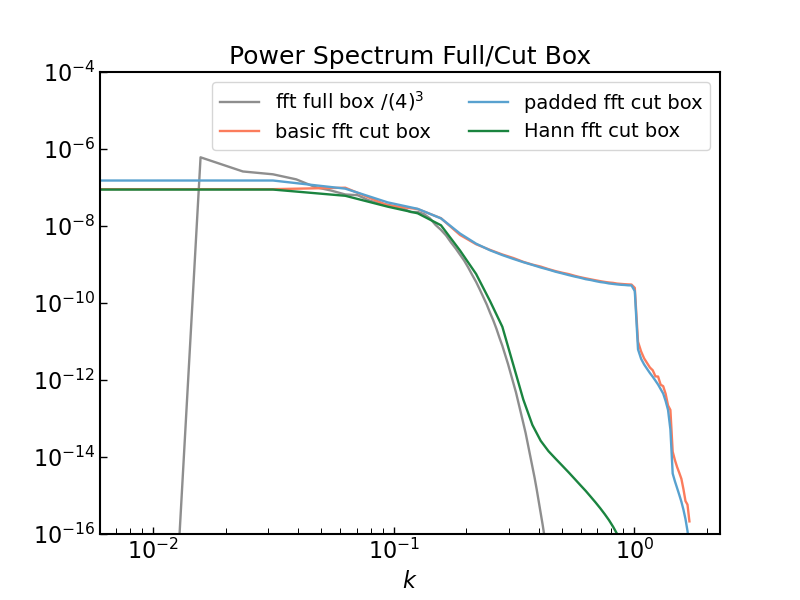

In [29]:
fig, ax = plt.subplots(figsize=(8,6))

tt = np.logspace(1,2, 100)

ax.plot(k1d, powerspectr/64, ls='-', color=grays[5],
        markerfacecolor='none', markersize=4, label=r'fft full box $/(4)^3$')

ax.plot(k1d_cut, powerspectr_cut, ls='-', color=reds[5],
        markerfacecolor='none', markersize=4, label=r'basic fft cut box')

ax.plot(k1d_padded, powerspectr_padded, ls='-', color=blues[4],
        markerfacecolor='none', markersize=4, label=r'padded fft cut box')

ax.plot(k1d_hann, powerspectr_hann, ls='-', color=greens[2],
        markerfacecolor='none', markersize=4, label=r'Hann fft cut box')

# ax.plot(k1d_kaiser, powerspectr_kaiser, ls='-', color=greens[7],
#         markerfacecolor='none', markersize=4, label=r'Kaiser fft cut box')


# ax.plot(tt, 1e3*tt**(-5./3.), ls='-', color='k',lw=1., label=r'$k^{-5/3}$')

ax.set_xlabel('$k$', fontsize=16)
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc='best',ncols=2,fontsize=14)

ax.set_title(r'Power Spectrum Full/Cut Box', fontsize=18)
# ax.set_xlabel((1/arepo_length).to('1/Mpc').label('k'),fontsize=16)
# ax.set_ylabel(r'$E_B(k)$',fontsize=16)
# ax.set_title('Magnetic energy',fontsize=18)

# ax.set_ylim(ymin=1e-25)
# ax.set_xlim(xmin=1e-2)
ax.set_ylim(ymin=1e-16, ymax=1e-4)
# ax[1].set_xlim(xmax=30)

plt.savefig('./power_spectrum_full_box_cut_box.pdf',dpi=400)
plt.show()


Text(0.5, 0.95, 'Density field (original and windowed)')

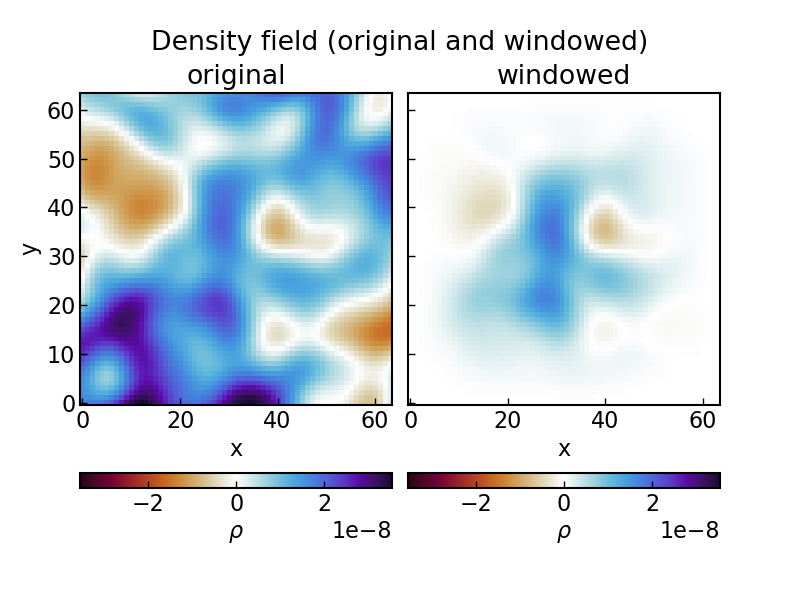

In [26]:
# dens_cart = density_cartesian[:,:,0]
dens_cart_cut = density_cartesian_cut[:,:,int(Nz_cut//2)-1]
dens_cart_hann = density_cartesian_cut_hann[:,:,int(Nz_cut//2)-1]

vmax = np.max(dens_cart_cut)
vmin = -vmax
# print(vmin)
# print(vmax)
# norm = LogNorm(vmin=vmin,vmax=vmax)
norm = Normalize(vmin=vmin,vmax=vmax)
# cmap = cmr.fall
cmap = cmr.fusion

fig, axes = plt.subplots(1,2, figsize=(8,6),sharex=True, sharey=True)

im1 = axes[0].imshow(
    dens_cart_cut, origin='lower', norm=norm, cmap=cmap)

im2 = axes[1].imshow(
    dens_cart_hann, origin='lower', norm=norm, cmap=cmap)

axes[0].set_title('original')
axes[1].set_title('windowed')

for i in range(2):
    axes[i].set_xlabel('x')

axes[0].set_ylabel('y')



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(r'$\rho$')

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(r'$\rho$')

fig.subplots_adjust(top=0.85,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Density field (original and windowed)',y=0.95)
plt.savefig('./cut_box_original_windowed_kolmogorov.pdf',dpi=400)
# plt.close()